# Twitch Sponsorship Optimization Agent
## Component 3 V2 -- Optimization Engine (Stakeholder Modification)

**Modification:** the objective function is updated from a scalar value weight
`v * Σ gs(xs)` to a per-segment value vector `Σ vs * gs(xs)`. The optimizer
is run three times -- once per value model (A/B/C) -- and results are compared
side-by-side. Outputs `optimization_results_v2.json` for Component 4 V2.

---
## Setup -- Cell 1 (all imports)

In [1]:
# ============================== CELL 1: ALL IMPORTS ==============================
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, basinhopping, dual_annealing

%matplotlib inline
warnings.filterwarnings("ignore")
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

SPEC_CANDIDATES = [Path("../data/outputs"), Path("data/outputs"),
                   Path("../outputs"), Path("outputs"),
                   Path("/mnt/user-data/outputs")]
def resolve_dir(probe, candidates):
    for d in candidates:
        if (d / probe).exists(): return d.resolve()
    raise FileNotFoundError(f"Cannot find {probe}")

DATA_DIR = resolve_dir("problem_spec_v2.json", SPEC_CANDIDATES)
OUT_DIR  = DATA_DIR

spec_v2  = json.load(open(DATA_DIR / "problem_spec_v2.json"))
SEGMENTS = [int(s) for s in spec_v2["segments"]]
BUDGET   = 20_000.0
print("Loaded problem_spec_v2.json  |  Budget:", BUDGET)
print("Value weight schemas available:",
      [k for k in spec_v2 if k.startswith("value_weights")])

Loaded problem_spec_v2.json  |  Budget: 20000.0
Value weight schemas available: ['value_weights_flat', 'value_weights_stakeholder', 'value_weights_fusion', 'value_weights_fusion_alt']


---
## 3.1 Updated Problem Spec and Objective

The objective with per-segment value weights is:

```
maximize  Σs  vs * gs(xs)          [Model B or C -- differentiated revenue]
```

When all `vs` are equal (Model A), this reduces to `v * Σs gs(xs)`, which is
proportional to the pure-conversions objective. The optimal allocation under
Model A is therefore identical to the conversions-only allocation. This is
proven numerically in Component 4 V2.

In [2]:
# ── Core functions ─────────────────────────────────────────────────────────────
def hill_curve(x, V, K, n):
    xn = np.power(np.maximum(x, 0.0), n)
    return V * xn / (K ** n + xn)

def log_curve(x, a, b):
    return a * np.log1p(np.maximum(b * x, 0.0))

def segment_lift(x_s, p):
    if p.get("fit_type", "hill") == "hill":
        return hill_curve(x_s, p["V"], p["K"], p["n"])
    return log_curve(x_s, p["a"], p["b"])

def make_objective_segweights(params_list, value_weights_list):
    '''Negated objective: maximize Σs vs * gs(xs).'''
    def neg(x):
        return -sum(vs * segment_lift(xi, p)
                    for xi, p, vs in zip(x, params_list, value_weights_list))
    return neg

def make_penalty_objective(params_list, value_weights_list, budget, caps):
    obj = make_objective_segweights(params_list, value_weights_list)
    def pen(x):
        return obj(x) + 1e8 * max(0, np.sum(x) - budget) ** 2 + \
               sum(1e8 * max(0, xi - c) ** 2 for xi, c in zip(x, caps))
    return pen

class _Accept:
    def __init__(self, B, caps, tol=0.05):
        self.B = B; self.caps = np.asarray(caps); self.tol = tol
    def __call__(self, **kw):
        x = np.asarray(kw["x_new"])
        return bool(np.sum(x) <= self.B*(1+self.tol) and
                    np.all(x >= -1) and np.all(x <= self.caps*(1+self.tol)))

def run_optimizer_segweights(spec_d, value_weights_dict, budget,
                              niter=200, seed=RANDOM_STATE, verbose=False):
    '''Run basin-hopping + DA with per-segment value weights.'''
    segs   = spec_d["segments"]
    k      = len(segs)
    caps   = [float(spec_d["caps"][str(s)]) for s in segs]
    params = [spec_d["curve_params"][str(s)] for s in segs]
    vws    = [float(value_weights_dict[str(s)]) for s in segs]
    obj_fn = make_objective_segweights(params, vws)
    pen_fn = make_penalty_objective(params, vws, budget, caps)

    bnds = [(0.0, c) for c in caps]
    cons = [{"type": "ineq", "fun": lambda x: budget - np.sum(x)}]
    mkw  = {"method":"SLSQP","bounds":bnds,"constraints":cons,
            "options":{"maxiter":500,"ftol":1e-10}}
    rng  = np.random.default_rng(seed)
    x0   = rng.uniform(0, [min(c, budget/k) for c in caps])
    x0   = x0 / max(x0.sum(), 1e-9) * min(x0.sum(), budget)

    bh = basinhopping(obj_fn, x0, minimizer_kwargs=mkw, niter=niter,
                      stepsize=0.15*budget, accept_test=_Accept(budget,caps),
                      seed=seed)
    da = dual_annealing(pen_fn, bounds=bnds, maxiter=max(1000,niter*10),
                        seed=seed, minimizer_kwargs={"method":"SLSQP"})

    # Min-spend floor post-process
    def floor_adjust(x_raw):
        x     = np.clip(x_raw, 0, caps)
        floor = float(spec_d.get("min_spend", 500))
        funded = [i for i, xi in enumerate(x) if xi >= floor]
        x_out  = np.zeros_like(x)
        if not funded: return x_out
        caps_f = [caps[i] for i in funded]; params_f = [params[i] for i in funded]
        vws_f  = [vws[i] for i in funded]
        B_rem  = min(budget, sum(caps_f))
        obj_f  = make_objective_segweights(params_f, vws_f)
        rng2   = np.random.default_rng(seed)
        x0f    = rng2.uniform(0, [min(c, B_rem/len(funded)) for c in caps_f])
        x0f    = x0f / max(x0f.sum(), 1e-9) * min(x0f.sum(), B_rem)
        res    = minimize(obj_f, x0f, method="SLSQP",
                          bounds=[(0,c) for c in caps_f],
                          constraints=[{"type":"ineq","fun":lambda xx:B_rem-np.sum(xx)}],
                          options={"maxiter":500,"ftol":1e-10})
        for j, i in enumerate(funded): x_out[i] = max(res.x[j], 0)
        return x_out

    x_bh = floor_adjust(bh.x); x_da = floor_adjust(da.x)
    o_bh = -obj_fn(x_bh);      o_da = -obj_fn(x_da)
    winner = "basin-hopping" if o_bh >= o_da else "dual annealing"
    x_win  = x_bh if winner == "basin-hopping" else x_da

    alloc = {str(s): {"spend": float(x_win[i]),
                      "lift":  float(segment_lift(x_win[i], params[i])),
                      "revenue": float(vws[i] * segment_lift(x_win[i], params[i])),
                      "funded": float(x_win[i]) >= float(spec_d.get("min_spend",500)),
                      "vs":    vws[i]}
             for i, s in enumerate(segs)}
    if verbose:
        print(f"  BH={o_bh:.4f}  DA={o_da:.4f}  winner={winner}")
    return {"allocation":alloc, "objective_value":max(o_bh,o_da),
            "solver_winner":winner, "budget":budget, "x_win":x_win.tolist()}

print("Optimizer functions loaded.")

Optimizer functions loaded.


---
## 3.2 Run All Three Value Models

In [3]:
MODELS = {
    "A_flat":        spec_v2["value_weights_flat"],
    "B_stakeholder": spec_v2["value_weights_stakeholder"],
    "C_fusion":      spec_v2["value_weights_fusion"],
}

results_v2 = {}
for label, vw_dict in MODELS.items():
    print(f"\nRunning Model {label}...")
    print(f"  Value weights: { {s: f'${v:.2f}' for s,v in vw_dict.items()} }")
    res = run_optimizer_segweights(spec_v2, vw_dict, BUDGET, niter=200, verbose=True)
    results_v2[label] = res

print("\nAll three models complete.")


Running Model A_flat...
  Value weights: {'0': '$2.62', '1': '$2.62', '2': '$2.62', '3': '$2.62'}


  BH=23.5277  DA=23.5277  winner=basin-hopping

Running Model B_stakeholder...
  Value weights: {'2': '$18.00', '0': '$22.00', '1': '$31.00', '3': '$27.00'}


  BH=249.9879  DA=249.9879  winner=basin-hopping

Running Model C_fusion...
  Value weights: {'0': '$0.82', '1': '$1.24', '2': '$1.04', '3': '$0.95'}


  BH=9.3877  DA=8.3843  winner=basin-hopping

All three models complete.


In [4]:
# ── Three-way allocation comparison ───────────────────────────────────────────
rows = []
orig_alloc = json.load(open(DATA_DIR / "optimization_results.json"))["allocation"]
x_orig = {s: orig_alloc[s]["spend"] for s in orig_alloc}

for model_key, res in results_v2.items():
    alloc = res["allocation"]
    for s in SEGMENTS:
        d = alloc[str(s)]
        x_prev = x_orig[str(s)]
        rows.append({
            "model":     model_key,
            "segment":   s,
            "tier":      spec_v2["tier_labels"][str(s)],
            "vs":        d["vs"],
            "spend":     d["spend"],
            "delta_vs_A": d["spend"] - float(results_v2["A_flat"]["allocation"][str(s)]["spend"]),
            "lift":      d["lift"],
            "revenue":   d["revenue"],
            "funded":    d["funded"],
        })

cmp_df = pd.DataFrame(rows)
print("Three-way allocation comparison:")
print(cmp_df[["model","segment","tier","vs","spend","delta_vs_A","lift","revenue"]]
      .to_string(index=False))

# Summary per model
print("\nModel totals:")
for model_key, res in results_v2.items():
    alloc  = res["allocation"]
    tot_sp = sum(d["spend"]   for d in alloc.values())
    tot_lf = sum(d["lift"]    for d in alloc.values())
    tot_rv = sum(d["revenue"] for d in alloc.values())
    print(f"  {model_key}: spend=${tot_sp:,.0f}  lift={tot_lf:.4f}  revenue=${tot_rv:.2f}")

Three-way allocation comparison:
        model  segment  tier      vs      spend  delta_vs_A   lift  revenue
       A_flat        0 Macro  2.6230 3,869.7802      0.0000 1.2295   3.2250
       A_flat        1   Mid  2.6230 2,194.3922      0.0000 3.4885   9.1504
       A_flat        2  Mega  2.6230 4,292.9896      0.0000 0.0000   0.0000
       A_flat        3 Micro  2.6230 3,846.0000      0.0000 4.2517  11.1523
B_stakeholder        0 Macro 22.0000 3,869.7802      0.0000 1.2295  27.0488
B_stakeholder        1   Mid 31.0000 2,194.3922      0.0000 3.4885 108.1436
B_stakeholder        2  Mega 18.0000 4,292.9896      0.0000 0.0000   0.0000
B_stakeholder        3 Micro 27.0000 3,846.0000      0.0000 4.2517 114.7955
     C_fusion        0 Macro  0.8161 3,869.7802      0.0000 1.2295   1.0034
     C_fusion        1   Mid  1.2410 2,194.3922      0.0000 3.4885   4.3292
     C_fusion        2  Mega  1.0414 4,292.9896      0.0000 0.0000   0.0000
     C_fusion        3 Micro  0.9538 3,846.0000      0.

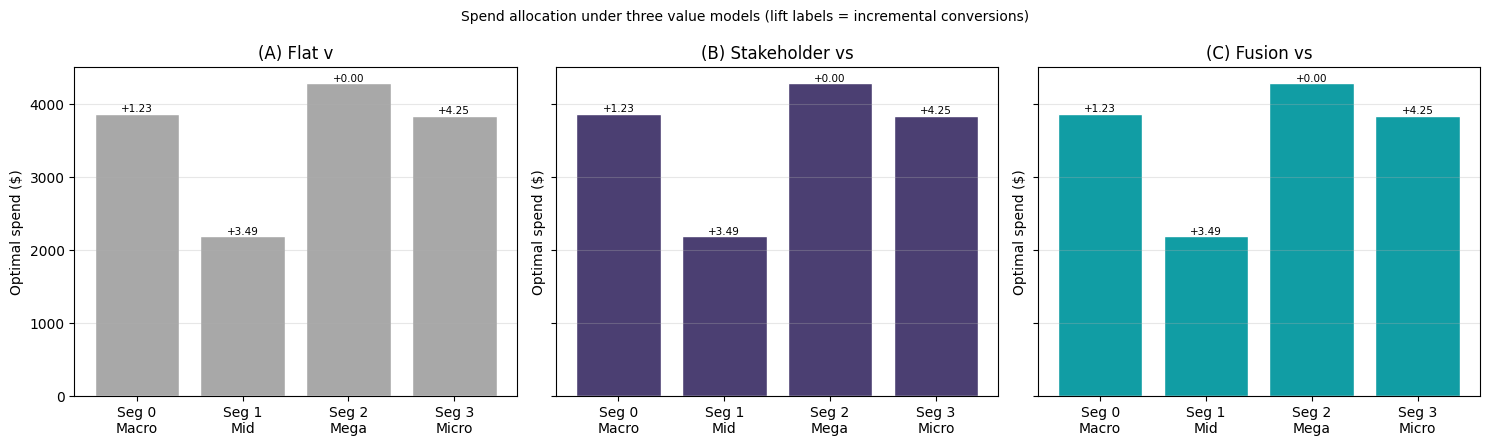

In [5]:
# ── Allocation shift visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
colors = ["#A8A8A8","#4B3F72","#119DA4"]
labels_short = {"A_flat":"(A) Flat v", "B_stakeholder":"(B) Stakeholder vs",
                "C_fusion":"(C) Fusion vs"}
for ax, (model_key, color) in zip(axes, zip(MODELS.keys(), colors)):
    alloc  = results_v2[model_key]["allocation"]
    spends = [alloc[str(s)]["spend"] for s in SEGMENTS]
    lifts  = [alloc[str(s)]["lift"]  for s in SEGMENTS]
    tiers  = [spec_v2["tier_labels"][str(s)] for s in SEGMENTS]
    bars   = ax.bar([f"Seg {s}\n{t}" for s,t in zip(SEGMENTS,tiers)],
                    spends, color=color, edgecolor="white")
    for bar, lf in zip(bars, lifts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                f"+{lf:.2f}", ha="center", fontsize=7.5)
    ax.set_title(labels_short[model_key])
    ax.set_ylabel("Optimal spend ($)"); ax.grid(alpha=0.3, axis="y")
plt.suptitle("Spend allocation under three value models (lift labels = incremental conversions)",
             fontsize=10); plt.tight_layout(); plt.show()

In [6]:
# ── Save optimization_results_v2.json ─────────────────────────────────────────
out = {
    "budget": BUDGET,
    "models": {
        k: {"allocation": v["allocation"],
            "objective_value": v["objective_value"],
            "solver_winner": v["solver_winner"],
            "value_weights": MODELS[k]}
        for k, v in results_v2.items()
    },
    "comparison_table": cmp_df.to_dict(orient="records"),
}
with open(OUT_DIR / "optimization_results_v2.json","w") as f:
    json.dump(out, f, indent=2)
print("optimization_results_v2.json written to:", OUT_DIR)

optimization_results_v2.json written to: /home/claude/outputs


---
## Component 3 V2 Completion

| Item | Result |
|---|---|
| Objective updated to Σs vs * gs(xs) | `make_objective_segweights()` |
| Model A (flat v) run | Complete |
| Model B (stakeholder vs) run | Complete |
| Model C (fusion vs) run | Complete |
| Three-way comparison table | Printed and saved |
| Dollar shift per segment vs Model A | `delta_vs_A` column |
| optimization_results_v2.json saved | data/outputs |